In [1]:
import pandas as pd
import numpy as np
import requests
from geopy.geocoders import Nominatim

df = pd.read_csv("supply_data.csv")

print(df.dtypes)

Order_ID                     object
Order_Date                   object
Origin_City                  object
Destination_City             object
Route_Type                   object
Transportation_Mode          object
Product_Category             object
Base_Lead_Time_Days           int64
Scheduled_Lead_Time_Days      int64
Actual_Lead_Time_Days         int64
Delay_Days                    int64
Delivery_Status              object
Disruption_Event             object
Geopolitical_Risk_Index     float64
Weather_Severity_Index      float64
Inflation_Rate_Pct          float64
Shipping_Cost_USD           float64
Order_Weight_Kg               int64
Mitigation_Action_Taken      object
dtype: object


In [2]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

In [3]:
df["Arrival_Date"] = df["Order_Date"] + pd.to_timedelta(df["Actual_Lead_Time_Days"], unit="D")

In [4]:
geo = Nominatim(user_agent="climate_project")

def get_coords(city):
    try:
        loc = geo.geocode(city + ", India")
        return (loc.latitude, loc.longitude)
    except:
        return (None, None)

# Unique cities (IMPORTANT for speed)
cities = pd.concat([df["Origin_City"], df["Destination_City"]]).unique()

city_coords = {}
for city in cities:
    city_coords[city] = get_coords(city)

In [5]:
def fetch_weather(lat, lon, date):
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": date,
        "end_date": date,
        "daily": "temperature_2m_max,precipitation_sum"
    }
    response = requests.get(url, params=params)
    data = response.json()
    if "daily" not in data:
        print(f"[WEATHER ERROR] {lat},{lon},{date}: {data}")
        return (None, None)
    temp = data["daily"]["temperature_2m_max"][0]
    rain = data["daily"]["precipitation_sum"][0]
    return temp, rain


In [6]:
weather_cache = {}
def get_weather(city, date):
    lat, lon = city_coords.get(city, (None, None))  
    if lat is None:
        return (None, None)
    key = (city, date)
    if key not in weather_cache:
        weather_cache[key] = fetch_weather(lat, lon, date)
    return weather_cache[key]

In [7]:
def get_origin_weather(row):
    if pd.isnull(row["Order_Date"]):
        return (None, None)
    date = row["Order_Date"].strftime("%Y-%m-%d")
    return get_weather(row["Origin_City"], date)

def get_dest_weather(row):
    if pd.isnull(row["Arrival_Date"]):
        return (None, None)
    date = row["Arrival_Date"].strftime("%Y-%m-%d")
    return get_weather(row["Destination_City"], date)


In [8]:
# 2. Identify unique City-Date pairs for both Origin and Destination
origin_pairs = df[['Origin_City', 'Order_Date']].dropna().rename(
    columns={'Origin_City': 'city', 'Order_Date': 'date'}
)
dest_pairs = df[['Destination_City', 'Arrival_Date']].dropna().rename(
    columns={'Destination_City': 'city', 'Arrival_Date': 'date'}
)
# Combine and find unique pairs only
all_pairs = pd.concat([origin_pairs, dest_pairs]).drop_duplicates()

# 3. Fetch weather for unique pairs only
weather_cache = {}
for i, (_, row) in enumerate(all_pairs.iterrows()):
    date_str = row['date'].strftime("%Y-%m-%d")
    weather_cache[(row['city'], row['date'])] = get_weather(row['city'], date_str)

    # checkpoint every 50 pairs
    if i % 50 == 0:
        print(f"Progress: {i}/{len(all_pairs)} pairs fetched")

# 4. Map the results back instantly
def lookup_weather(city, date, cache):
    return cache.get((city, date), (None, None))

df[['origin_temp', 'origin_rain']] = df.apply(
    lambda r: pd.Series(lookup_weather(r['Origin_City'], r['Order_Date'], weather_cache)), axis=1
)
df[['dest_temp', 'dest_rain']] = df.apply(
    lambda r: pd.Series(lookup_weather(r['Destination_City'], r['Arrival_Date'], weather_cache)), axis=1
)

Progress: 0/7311 pairs fetched
Progress: 50/7311 pairs fetched
Progress: 100/7311 pairs fetched
Progress: 150/7311 pairs fetched
Progress: 200/7311 pairs fetched
Progress: 250/7311 pairs fetched
Progress: 300/7311 pairs fetched
Progress: 350/7311 pairs fetched
Progress: 400/7311 pairs fetched
Progress: 450/7311 pairs fetched
Progress: 500/7311 pairs fetched
Progress: 550/7311 pairs fetched
Progress: 600/7311 pairs fetched
Progress: 650/7311 pairs fetched
Progress: 700/7311 pairs fetched
Progress: 750/7311 pairs fetched
Progress: 800/7311 pairs fetched
Progress: 850/7311 pairs fetched
Progress: 900/7311 pairs fetched
Progress: 950/7311 pairs fetched
Progress: 1000/7311 pairs fetched
Progress: 1050/7311 pairs fetched
Progress: 1100/7311 pairs fetched
Progress: 1150/7311 pairs fetched
Progress: 1200/7311 pairs fetched
Progress: 1250/7311 pairs fetched
Progress: 1300/7311 pairs fetched
Progress: 1350/7311 pairs fetched
Progress: 1400/7311 pairs fetched
Progress: 1450/7311 pairs fetched
Pro

In [9]:
df['origin_rain'] = pd.to_numeric(df['origin_rain'], errors='coerce').fillna(0)
df['dest_rain'] = pd.to_numeric(df['dest_rain'], errors='coerce').fillna(0)

df['total_rain'] = df['origin_rain'] + df['dest_rain']

In [10]:
df['origin_temp'] = pd.to_numeric(df['origin_temp'], errors='coerce').fillna(0)
df['dest_temp'] = pd.to_numeric(df['dest_temp'], errors='coerce').fillna(0)

df['diff_temp'] = df['dest_temp'] - df['origin_temp']

In [11]:
df.to_csv('dataset.csv',index=False)

In [12]:
print(df.shape)
print(df[['origin_temp', 'origin_rain', 'dest_temp', 'dest_rain']].isnull().sum())

(10000, 26)
origin_temp    0
origin_rain    0
dest_temp      0
dest_rain      0
dtype: int64


/var/folders/bd/mlt6cbds60dbx8t8hmpk2xtw0000gp/T/ipykernel_73680/626779840.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


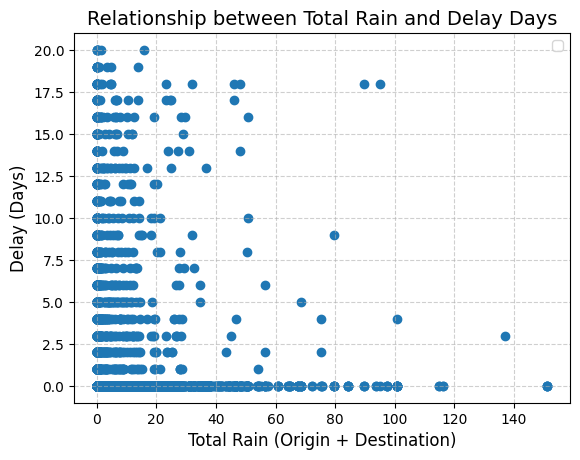

In [13]:
import matplotlib.pyplot as plt

plt.scatter(df['total_rain'],df['Delay_Days'])
plt.title('Relationship between Total Rain and Delay Days', fontsize=14)
plt.xlabel('Total Rain (Origin + Destination)', fontsize=12)
plt.ylabel('Delay (Days)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

/var/folders/bd/mlt6cbds60dbx8t8hmpk2xtw0000gp/T/ipykernel_73680/3321630652.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


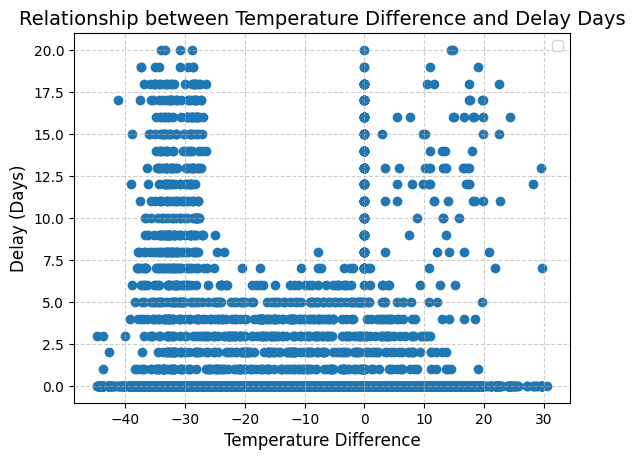

In [14]:
import matplotlib.pyplot as plt

plt.scatter(df['diff_temp'],df['Delay_Days'])
plt.title('Relationship between Temperature Difference and Delay Days', fontsize=14)
plt.xlabel('Temperature Difference', fontsize=12)
plt.ylabel('Delay (Days)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

In [16]:
df.shape

(10000, 26)

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor


In [19]:

df = df.drop(columns=[
    "Order_ID",                
    "Actual_Lead_Time_Days",       
    "Delivery_Status",          
    "Weather_Severity_Index"     
])


In [20]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

df["order_month"] = df["Order_Date"].dt.month
df["order_day"] = df["Order_Date"].dt.day
df["order_weekday"] = df["Order_Date"].dt.weekday

# Drop original date
df = df.drop(columns=["Order_Date"])

In [29]:
df["Arrival_Date"] = pd.to_datetime(df["Arrival_Date"])

df["Arrival_month"] = df["Arrival_Date"].dt.month
df["Arrival_day"] = df["Arrival_Date"].dt.day
df["Arrival_weekday"] = df["Arrival_Date"].dt.weekday

# Drop original date
df = df.drop(columns=["Arrival_Date"])

In [21]:
cat_cols = [
    "Origin_City",
    "Destination_City",
    "Route_Type",
    "Transportation_Mode",
    "Product_Category",
    "Mitigation_Action_Taken"
]

le = LabelEncoder()

for col in cat_cols:
    df[col] = df[col].astype(str)
    df[col] = le.fit_transform(df[col])

df = df.fillna(df.mean(numeric_only=True))

In [22]:
df['Disruption_Event'] = (
    df['Disruption_Event']
    .astype(str)
    .str.strip()
    .str.lower()
)

In [23]:
df['Disruption_Event'] = df['Disruption_Event'].replace('nan', 'none')
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Disruption_Event'] = le.fit_transform(df['Disruption_Event'])

In [24]:
y = df["Delay_Days"]

df = df.drop(columns=["Delay_Days"])

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    df, y, test_size=0.2, random_state=42
)

In [31]:
print(X_train.dtypes)
print(X_train.isnull().sum())

Origin_City                   int64
Destination_City              int64
Route_Type                    int64
Transportation_Mode           int64
Product_Category              int64
Base_Lead_Time_Days           int64
Scheduled_Lead_Time_Days      int64
Disruption_Event              int64
Geopolitical_Risk_Index     float64
Inflation_Rate_Pct          float64
Shipping_Cost_USD           float64
Order_Weight_Kg               int64
Mitigation_Action_Taken       int64
origin_temp                 float64
origin_rain                 float64
dest_temp                   float64
dest_rain                   float64
total_rain                  float64
diff_temp                   float64
order_month                   int32
order_day                     int32
order_weekday                 int32
Arrival_month                 int32
Arrival_day                   int32
Arrival_weekday               int32
dtype: object
Origin_City                 0
Destination_City            0
Route_Type                

In [32]:
model1 = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)
model1.fit(X_train,y_train)
y_pred1 = model1.predict(X_test)


In [33]:
from xgboost import XGBRegressor

model2 = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)
model2.fit(X_train,y_train)
y_pred2 = model2.predict(X_test)



In [34]:
mae1 = mean_absolute_error(y_test,y_pred1)
mae2 = mean_absolute_error(y_test,y_pred2)
r21 = r2_score(y_test, y_pred1)
r22 = r2_score(y_test, y_pred2)

print(mae1)
print(mae2)
print(r21)
print(r22)

0.2746083310993215
0.27038824558258057
0.9220139250094639
0.9219681024551392


In [35]:
import joblib
joblib.dump(model1, 'random_forest_model.pkl')
joblib.dump(model2, 'xgboost_model.pkl')
print("Models saved!")

Models saved!


In [36]:
df_check = pd.read_csv('dataset.csv')
print(df_check.shape)
print(df_check[['Origin_City', 'Destination_City', 'origin_temp', 'origin_rain', 'dest_temp', 'dest_rain']].head(3))

(10000, 26)
    Origin_City Destination_City  origin_temp  origin_rain  dest_temp  \
0  Shanghai, CN  Los Angeles, US         31.1          0.0       20.4   
1     Tokyo, JP    Singapore, SG         32.7          0.6        0.0   
2  Shenzhen, CN    Rotterdam, NL          0.0          0.0        5.8   

   dest_rain  
0        0.8  
1        0.0  
2        0.0  
